<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [1]:
# Your code to import matplotlib, pandas and numpy libraries

#
#
#


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

_______________________![image.png](attachment:a4e07154-e766-4e74-a203-c09e7605ea7b.png)

In [3]:
import tensorflow as tf
from tensorflow import keras

__________________![image.png](attachment:06d151d2-f461-411d-8325-a4a6287cfd48.png)

In [4]:
print(tf.__version__)

2.20.0


____________________![image.png](attachment:3ff556fc-1f76-4be4-a216-1e8aecd11e54.png)

In [5]:
from keras.layers import Dense, Input

from keras.models import Model

from keras.datasets import mnist

In [6]:
# Your code to load MNIST data and store it in variables x_train, x_test.
# Note -  we do not need labels as it's autoencoder.

#



In [7]:
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


______________________![image.png](attachment:74823cdf-09eb-4a7a-8a39-8c306d6de031.png)

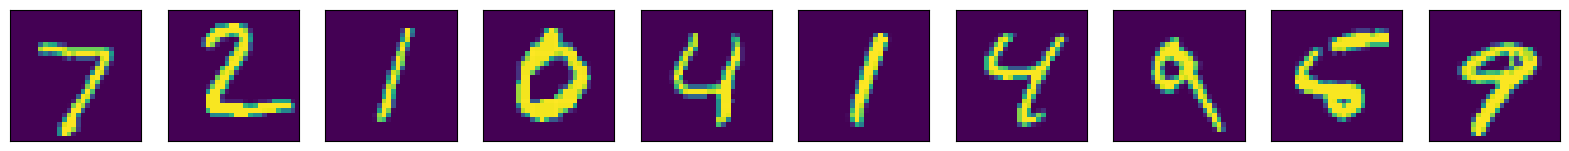

In [8]:
n =10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [9]:
# Your code to
# normalise train data - Divided by 255

#

# normalise test data - Divided by 255

x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning.


________________________![image.png](attachment:de80ae8e-d8d5-4cfc-a51b-a2f7d50dc7c2.png)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import SGD

In [11]:
encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(Dense(50, activation='relu'))
encoder.add(Dense(25, activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# Your code to print your Encoder model
print(encoder.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,525 (158.30 KB)

 Trainable params: 40,525 (158.30 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
decoder = Sequential()
decoder.add(Dense(25, input_shape=[25], activation='relu'))
decoder.add(Dense(50, activation='relu'))
decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Your code to print the Decoder model

#


In [15]:
print(decoder.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │        39,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,934 (163.80 KB)

 Trainable params: 41,934 (163.80 KB)

 Non-trainable params: 0 (0.00 B)

None


____________________![image.png](attachment:a94c2e5b-e27d-4e12-84c9-116a2f70e393.png)

In [16]:
autoencoder = Sequential([encoder, decoder])
print(autoencoder.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 25)             │        40,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │        41,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,459 (322.11 KB)

 Trainable params: 82,459 (322.11 KB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
print(autoencoder.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 25)             │        40,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │        41,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,459 (322.11 KB)

 Trainable params: 82,459 (322.11 KB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
#SGD?

In [19]:
# Your code to compile the Autoencoder.
# Use binary_crossenropy as loss and metrics as accuracy.


autoencoder.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

___________________![image.png](attachment:c8684fc7-fcb0-48bf-87e8-f70857a0fc4e.png)

____________________![image.png](attachment:30a3bc58-49bd-4849-8c76-e2551d3a033b.png)

In [20]:
history = autoencoder.fit(x_train, x_train, epochs=44, validation_data=(x_test, x_test))

Epoch 1/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.0277 - loss: 0.6904 - val_accuracy: 0.0298 - val_loss: 0.6867
Epoch 2/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0307 - loss: 0.6732 - val_accuracy: 0.0335 - val_loss: 0.6296
Epoch 3/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0539 - loss: 0.3928 - val_accuracy: 0.0661 - val_loss: 0.2804
Epoch 4/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0681 - loss: 0.2761 - val_accuracy: 0.0660 - val_loss: 0.2727
Epoch 5/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0687 - loss: 0.2718 - val_accuracy: 0.0693 - val_loss: 0.2701
Epoch 6/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0689 - loss: 0.2697 - val_accuracy: 0.0684 - val_loss: 0.2685
Epoch 7/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0690 - loss: 0.2683 - val_accuracy: 0.0684 - val_loss: 0.2673
Epoch 8/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0691 - loss: 0.26

___________________![image.png](attachment:b2f19fbc-57fa-40f7-80a1-336642829de1.png)

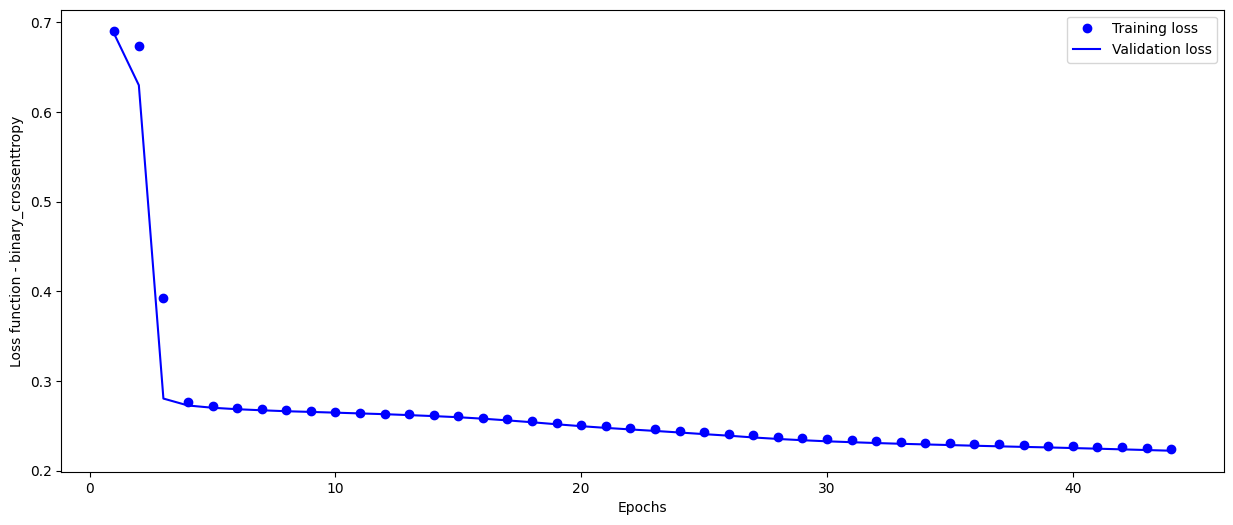

In [21]:
losses = history.history['loss']
val_losses = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(figsize=(15, 6))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossenttropy')
plt.legend()
plt.show()

_______________________![image.png](attachment:39f152ac-8692-403f-a1c4-3a71fe4fd978.png)

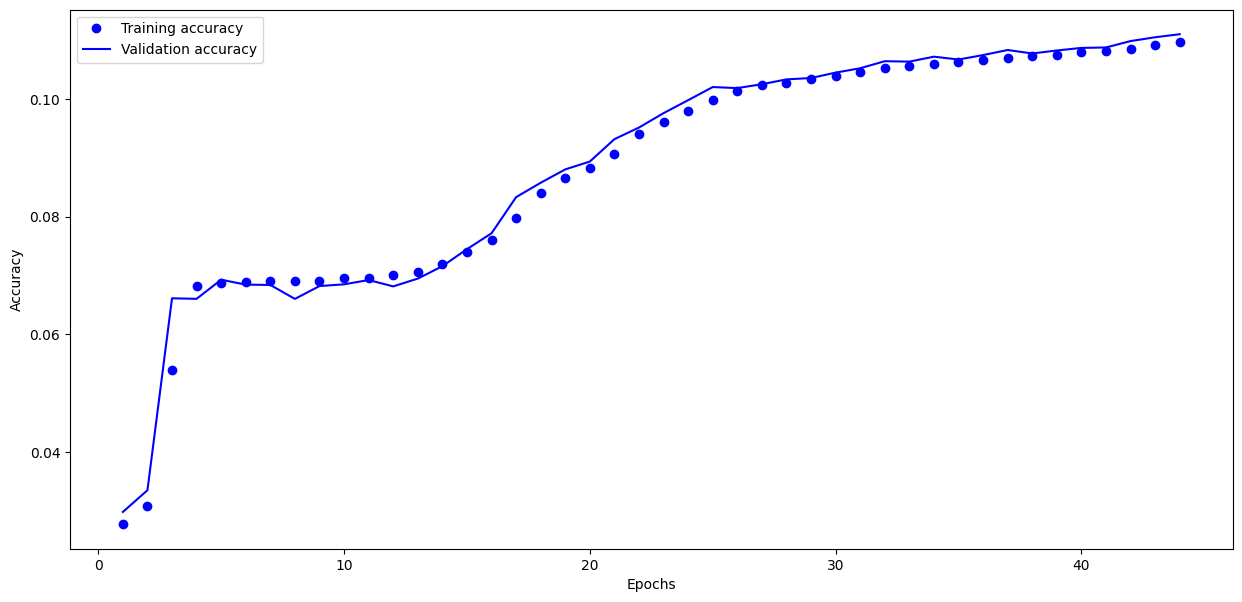

In [22]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)
plt.figure(figsize=(15, 7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


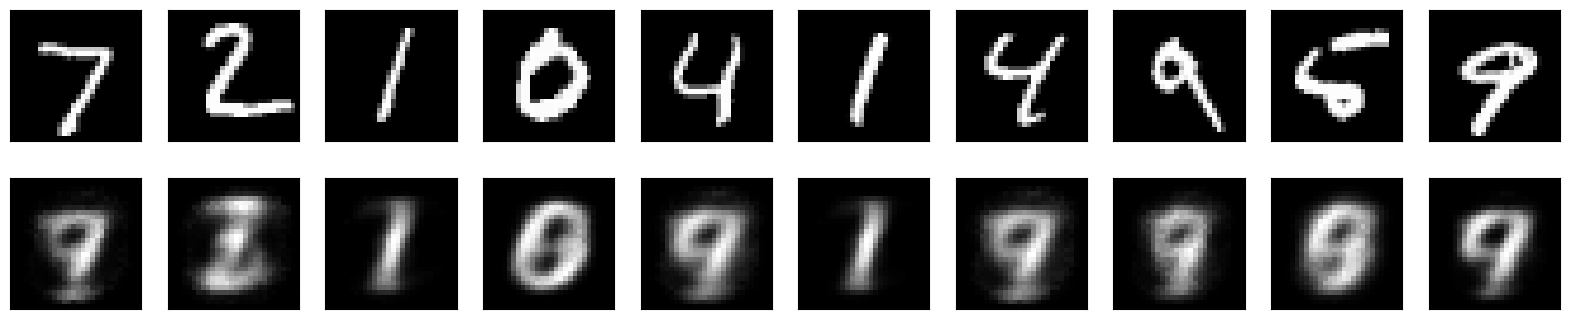

In [23]:
decoded_images = autoencoder.predict(x_test)
n=10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i +1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples.


______________________![image.png](attachment:66c883c0-27ea-473a-bfbf-adf60d8af39f.png)

In [24]:
from tensorflow.keras.layers import GaussianNoise

In [25]:
#GaussianNoise?

___________________![image.png](attachment:daef4479-63f7-4a6a-9927-be13f2230632.png)

In [26]:
sample = GaussianNoise(0.2)
noisey = sample(x_test[0:2],training=True)

In [27]:
# Plot the original and noisy images

_______________________![image.png](attachment:4013cb09-7c0a-4cc7-b208-31bda1d0f668.png)

In [28]:
x_test[0].size

784

____________________![image.png](attachment:2e2bac52-3120-4879-9117-f71bdf1ac965.png)

<function matplotlib.pyplot.show(close=None, block=None)>

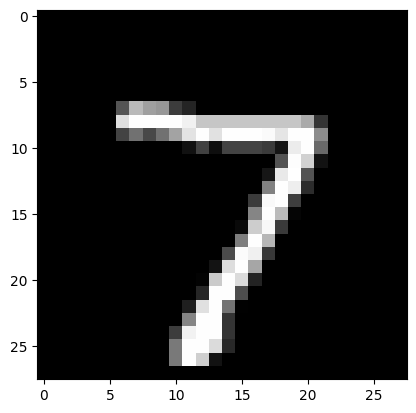

In [29]:
plt.imshow(x_test[0])
plt.show

_____________________![image.png](attachment:003958e0-35f7-4d32-8faf-b9486b5d206f.png)

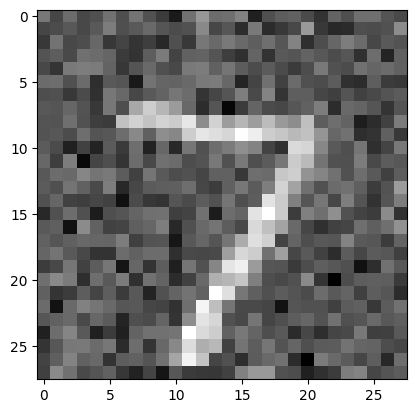

In [30]:
plt.imshow(noisey[0])
plt.show()

_________![image.png](attachment:dd745f81-2f9e-4b45-b030-3a4529ea6f1d.png)

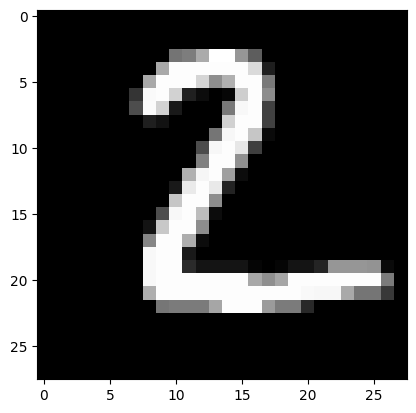

In [31]:
plt.imshow(x_test[1])
plt.show()

______________________![image.png](attachment:cf4f913b-10d4-47b9-9d91-b22fd1c175fa.png)

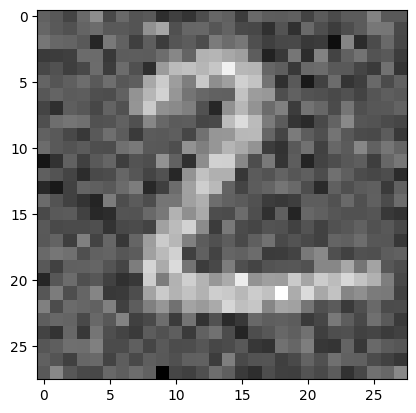

In [32]:
plt.imshow(noisey[1])
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network.
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [33]:
encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(GaussianNoise(0.2)) # We are adding noise to make input as noisy images

# Add layers of Encoder network. You could use the same number of layers as you created earlier
encoder.add(Dense(50, activation='relu'))
encoder.add(Dense(25, activation='relu'))

print(encoder.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 784)            │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,525 (158.30 KB)

 Trainable params: 40,525 (158.30 KB)

 Non-trainable params: 0 (0.00 B)

None


In [34]:
# Your OWN Encoder model should be printed here
# Please do not copy the model below

In [35]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

# Add layers of the Decoder network. You could use the same number of layers as you created earlier
# Reember - Encoder and Decoder must be symmetric


decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

print(decoder.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │        39,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,284 (161.27 KB)

 Trainable params: 41,284 (161.27 KB)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
print(decoder.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │        39,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,284 (161.27 KB)

 Trainable params: 41,284 (161.27 KB)

 Non-trainable params: 0 (0.00 B)

None


_________________________![image.png](attachment:b8742807-43dd-41a1-a461-c2a4455e6d07.png)

In [37]:
# Your code to print the Autoencoder model

#

In [38]:
noise_remover = Sequential([encoder, decoder])
print(noise_remover.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 25)             │        40,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28)         │        41,284 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,809 (319.57 KB)

 Trainable params: 81,809 (319.57 KB)

 Non-trainable params: 0 (0.00 B)

None


In [39]:

print(noise_remover.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 25)             │        40,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28)         │        41,284 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,809 (319.57 KB)

 Trainable params: 81,809 (319.57 KB)

 Non-trainable params: 0 (0.00 B)

None


In [40]:
# Your OWN Autoencoder model should be printed here

In [41]:
# Your code to compile the 'noise_remover' model with the same parameters as earlier

# noise_remover.compile( ................  )

noise_remover.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
# Your code to fit 'noise_remover' model with the same parameters as earlier

# history_2 = ..........................

history_2 = noise_remover.fit(x_train, x_train, epochs=44, validation_data=(x_test, x_test))

Epoch 1/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.1855 - loss: 0.1670 - val_accuracy: 0.2277 - val_loss: 0.1251
Epoch 2/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2371 - loss: 0.1227 - val_accuracy: 0.2454 - val_loss: 0.1107
Epoch 3/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.2475 - loss: 0.1147 - val_accuracy: 0.2549 - val_loss: 0.1057
Epoch 4/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.2529 - loss: 0.1113 - val_accuracy: 0.2603 - val_loss: 0.1038
Epoch 5/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2551 - loss: 0.1095 - val_accuracy: 0.2590 - val_loss: 0.1015
Epoch 6/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2567 - loss: 0.1084 - val_accuracy: 0.2589 - val_loss: 0.1011
Epoch 7/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2573 - loss: 0.1078 - val_accuracy: 0.2628 - val_loss: 0.1000
Epoch 8/44
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2590 - loss: 0

In [43]:
# Hint: Use (copy and modify) the code from the cells above

___________________![image.png](attachment:05682556-9ec1-46c6-85d5-3db97ba3c04f.png)

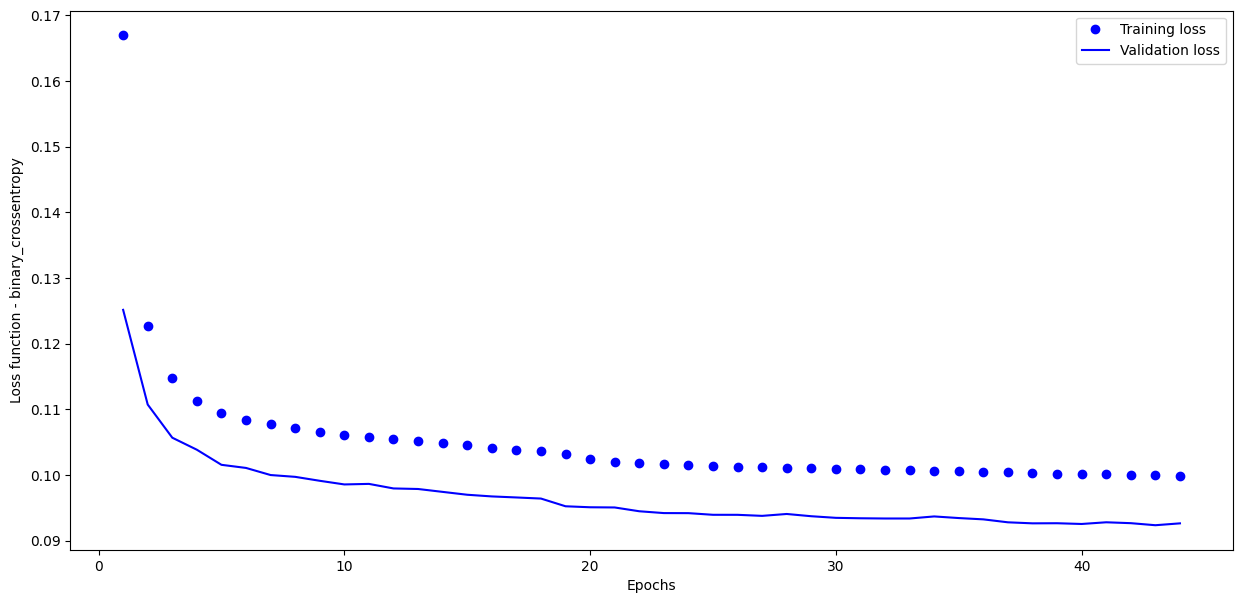

In [44]:
losses = history_2.history['loss']
losses_val = history_2.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15, 7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()

plt.show()

___________________________![image.png](attachment:43697532-dcb7-41bf-a1fa-6f630f5d4a29.png)

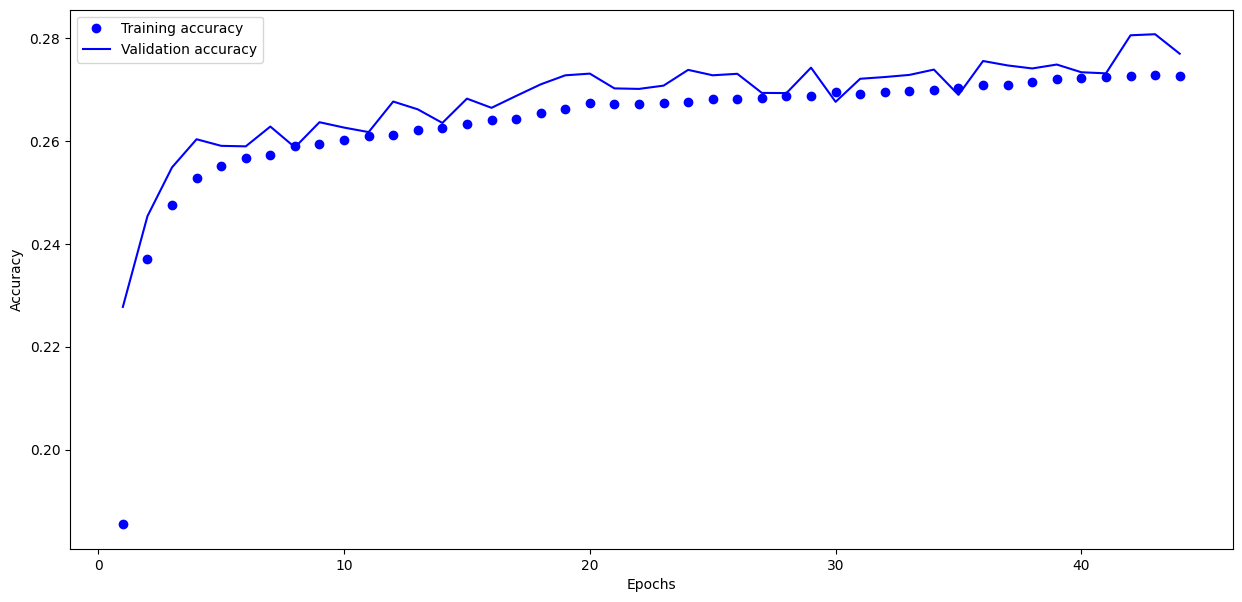

In [45]:
accuracy_array = history_2.history['accuracy']
val_accuracy_array = history_2.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)
plt.figure(figsize=(15, 7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

______________________![image.png](attachment:9dbf1489-73d6-4480-adc7-0ced14e0c9dd.png)

In [46]:

hundred_noisey_images = sample(x_test[0:100],training=True)
denoised= noise_remover(hundred_noisey_images[0:100])

______________________![image.png](attachment:a5bc2008-bc25-45e7-97ba-ae44dffae6ed.png)

In [47]:
import random

_______![image.png](attachment:505ed502-6fd8-4f58-a27f-44a804f20493.png)

41
The Original


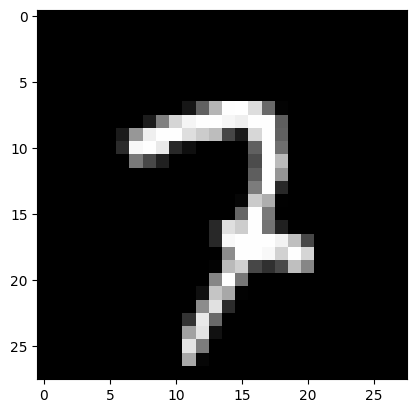

The Noisey Version


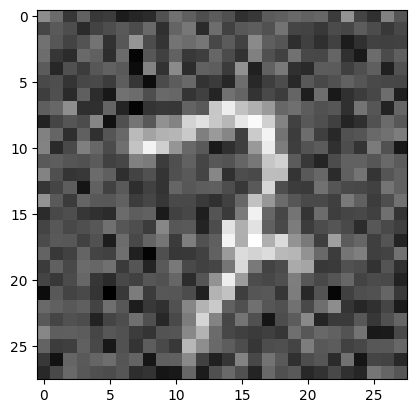

After going through denoiser


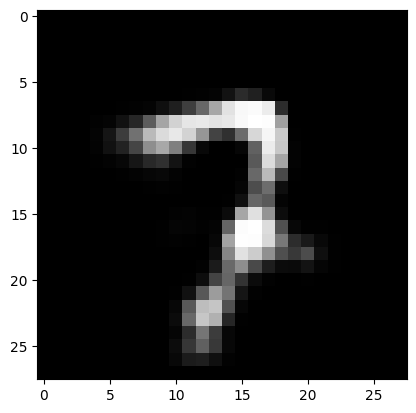

In [48]:
import random

n = random.randint(0, 100)

print(n)

print("The Original")
plt.imshow(x_test[n])
plt.show()

print("The Noisey Version")
plt.imshow(hundred_noisey_images[n])
plt.show()

print("After going through denoiser")
plt.imshow(denoised[n])
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.